In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from decimal import Decimal, ROUND_HALF_UP
from xgboost import XGBRegressor

In [54]:
df = pd.read_csv('train_data.csv')

In [55]:
test_data = pd.read_csv('test_data.csv')

In [56]:
test_data_raw = test_data.copy()

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1200 non-null   int64  
 1   journal_text        1200 non-null   object 
 2   ambience_type       1200 non-null   object 
 3   duration_min        1200 non-null   int64  
 4   sleep_hours         1193 non-null   float64
 5   energy_level        1200 non-null   int64  
 6   stress_level        1200 non-null   int64  
 7   time_of_day         1200 non-null   object 
 8   previous_day_mood   1185 non-null   object 
 9   face_emotion_hint   1077 non-null   object 
 10  reflection_quality  1200 non-null   object 
 11  emotional_state     1200 non-null   object 
 12  intensity           1200 non-null   int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 122.0+ KB


In [58]:
df.isnull().sum()

id                      0
journal_text            0
ambience_type           0
duration_min            0
sleep_hours             7
energy_level            0
stress_level            0
time_of_day             0
previous_day_mood      15
face_emotion_hint     123
reflection_quality      0
emotional_state         0
intensity               0
dtype: int64

In [59]:
df.describe()

,id,duration_min,sleep_hours,energy_level,stress_level,intensity
count,1200.000000,1200.000000,1193.000000,1200.000000,1200.000000,1200.000000
mean,564.500000,15.861667,5.989522,3.016667,3.026667,3.045833
std,304.731523,7.671369,1.500732,1.381296,1.401520,1.391766
min,1.000000,3.000000,3.500000,1.000000,1.000000,1.000000
25%,300.750000,10.000000,5.000000,2.000000,2.000000,2.000000
50%,600.500000,15.000000,6.000000,3.000000,3.000000,3.000000
75%,810.250000,20.000000,7.000000,4.000000,4.000000,4.000000
max,1080.000000,35.000000,8.500000,5.000000,5.000000,5.000000


In [60]:
df['emotional_state'].value_counts()

emotional_state
calm           216
restless       209
neutral        201
focused        193
mixed          191
overwhelmed    190
Name: count, dtype: int64

In [61]:
df['time_of_day'].value_counts()

time_of_day
afternoon        319
morning          302
night            286
evening          268
early_morning     25
Name: count, dtype: int64

In [62]:
test_data['time_of_day'].value_counts()

time_of_day
afternoon    33
morning      32
evening      29
night        26
Name: count, dtype: int64

In [63]:
df['time_of_day'] = df['time_of_day'].replace('early_morning', 'morning')

In [64]:
df['face_emotion_hint'].value_counts()

face_emotion_hint
neutral_face    214
calm_face       197
none            174
happy_face      173
tense_face      164
tired_face      155
Name: count, dtype: int64

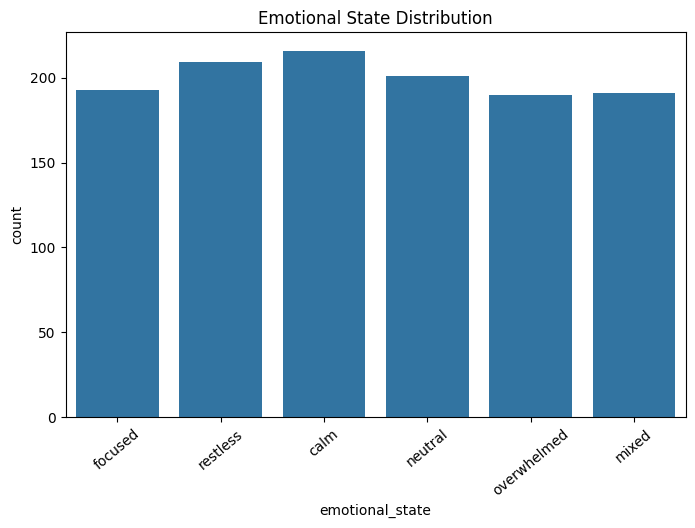

In [65]:
plt.figure(figsize=(8,5))
sns.countplot(x='emotional_state', data=df)
plt.xticks(rotation=40)
plt.title("Emotional State Distribution")
plt.show()


In [66]:
df['intensity'].value_counts()

intensity
4    277
3    240
5    229
2    228
1    226
Name: count, dtype: int64

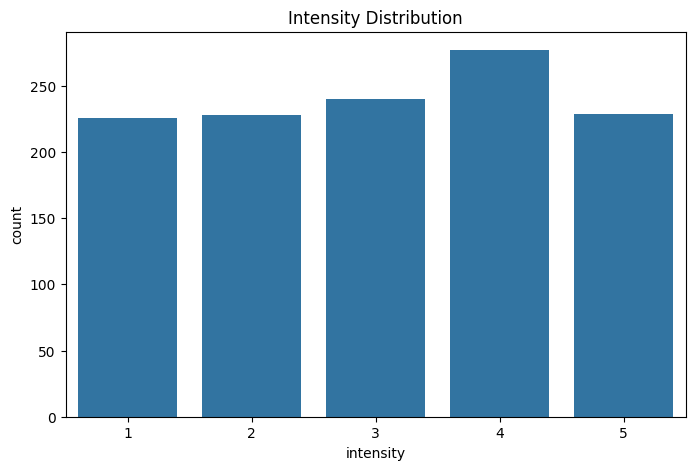

In [67]:
plt.figure(figsize=(8,5))
sns.countplot(x='intensity', data=df)
plt.xticks(rotation=0)
plt.title("Intensity Distribution")
plt.show()


<Axes: xlabel='sleep_hours'>

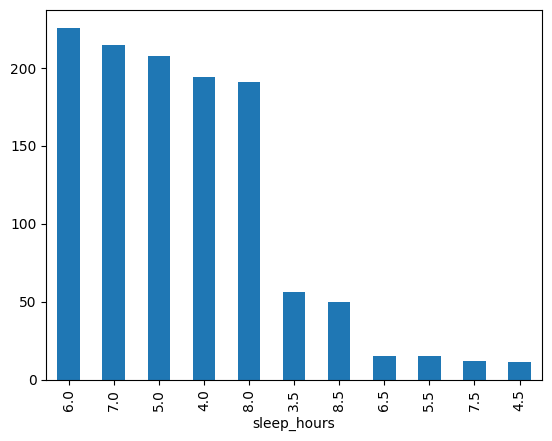

In [68]:
df['sleep_hours'].value_counts().plot(kind='bar')

<Axes: xlabel='stress_level'>

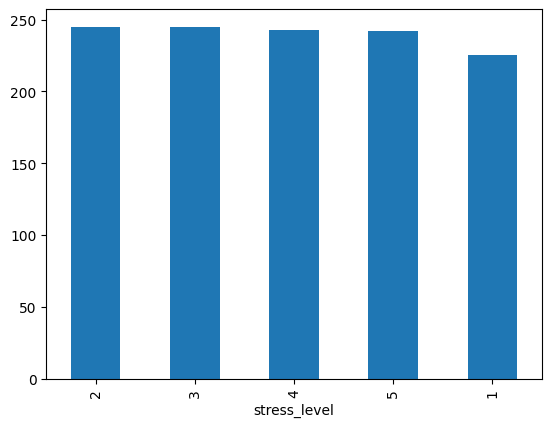

In [69]:
df['stress_level'].value_counts().plot(kind='bar')

<Axes: xlabel='energy_level'>

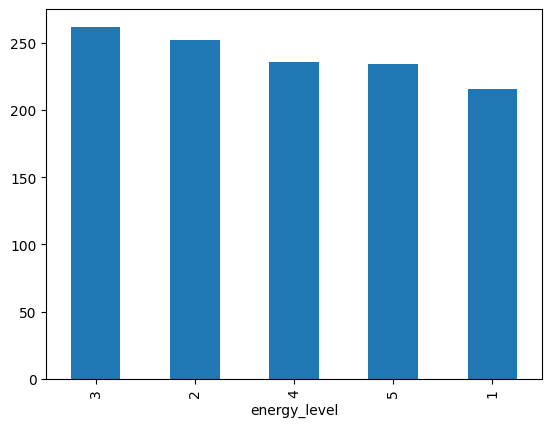

In [70]:
df['energy_level'].value_counts().plot(kind='bar')

<Axes: xlabel='time_of_day'>

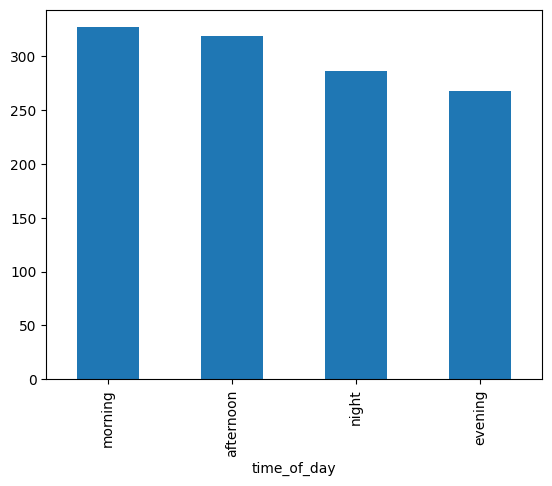

In [71]:
df['time_of_day'].value_counts().plot(kind='bar')

<Axes: xlabel='ambience_type'>

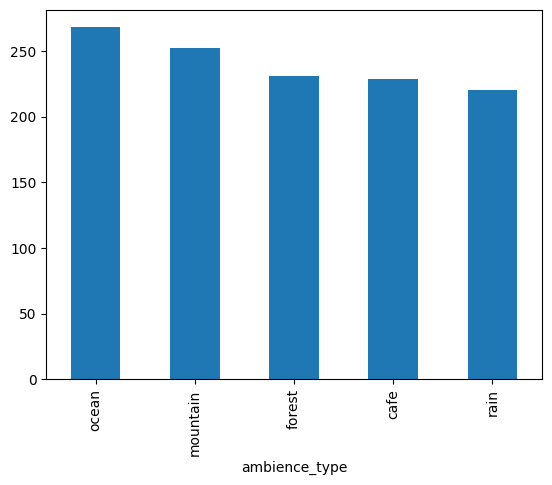

In [72]:
df['ambience_type'].value_counts().plot(kind='bar')

In [73]:
df.columns

Index(['id', 'journal_text', 'ambience_type', 'duration_min', 'sleep_hours',
       'energy_level', 'stress_level', 'time_of_day', 'previous_day_mood',
       'face_emotion_hint', 'reflection_quality', 'emotional_state',
       'intensity'],
      dtype='object')

In [74]:
df['text_length'] = df['journal_text'].astype(str).apply(len)
test_data['text_length'] = test_data['journal_text'].astype(str).apply(len)

In [75]:
df['text_length'].describe()

count    1200.000000
mean       58.325000
std        28.348529
min         9.000000
25%        33.000000
50%        61.000000
75%        74.000000
max       169.000000
Name: text_length, dtype: float64

<Axes: ylabel='Frequency'>

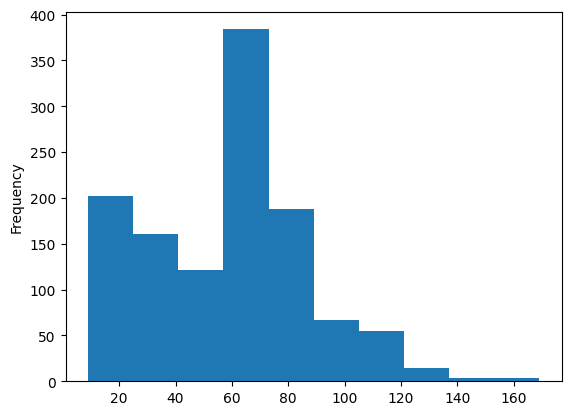

In [76]:
df['text_length'].plot(kind='hist')

In [77]:
df[df['text_length']<15]

,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality,emotional_state,intensity,text_length
485,486,kinda calm now,rain,25,5.0,4,4,night,neutral,neutral_face,vague,overwhelmed,2,14
486,487,felt heavy,cafe,5,5.0,2,1,night,neutral,neutral_face,clear,overwhelmed,3,10
497,498,kinda calm now,ocean,12,4.0,4,3,evening,overwhelmed,happy_face,conflicted,focused,5,14
523,524,felt heavy,forest,20,6.0,2,5,afternoon,calm,tense_face,vague,calm,5,10
529,530,it was fine,ocean,15,7.0,4,2,afternoon,neutral,none,clear,calm,3,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1184,1065,kinda calm,cafe,18,3.5,2,5,afternoon,mixed,tense_face,clear,focused,4,10
1187,1068,felt better,ocean,18,7.0,5,2,evening,restless,NaN,conflicted,mixed,3,11
1188,1069,okay session,cafe,7,8.0,3,3,night,neutral,happy_face,conflicted,focused,4,12
1191,1072,still heavy,ocean,30,8.0,3,1,afternoon,neutral,calm_face,conflicted,overwhelmed,4,11


<Axes: >

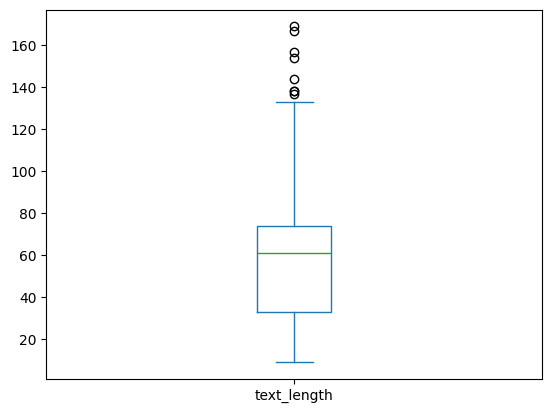

In [78]:
df['text_length'].plot(kind='box')

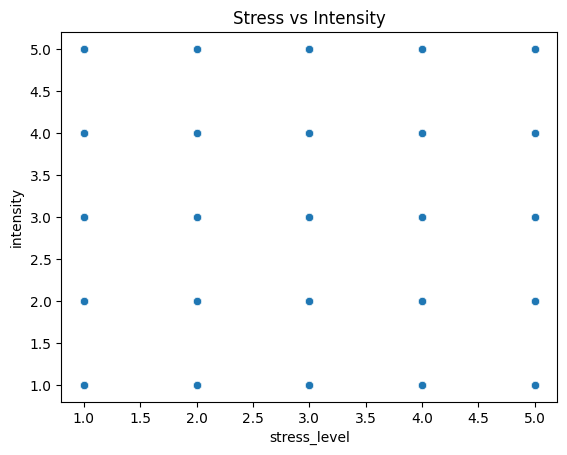

In [79]:
sns.scatterplot(x='stress_level', y='intensity', data=df)
plt.title("Stress vs Intensity")
plt.show()

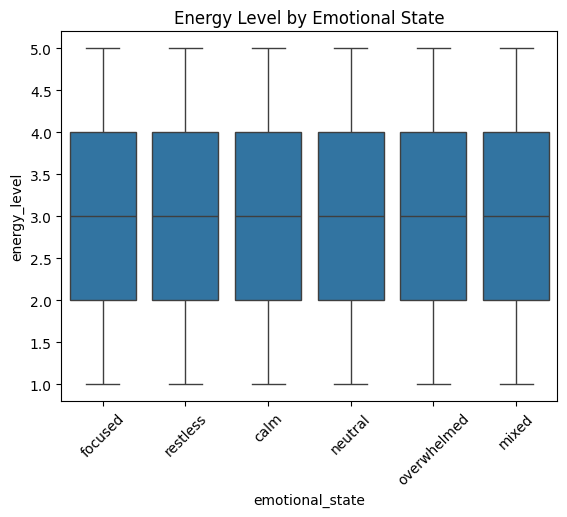

In [80]:
sns.boxplot(x='emotional_state', y='energy_level', data=df)
plt.xticks(rotation=45)
plt.title("Energy Level by Emotional State")
plt.show()


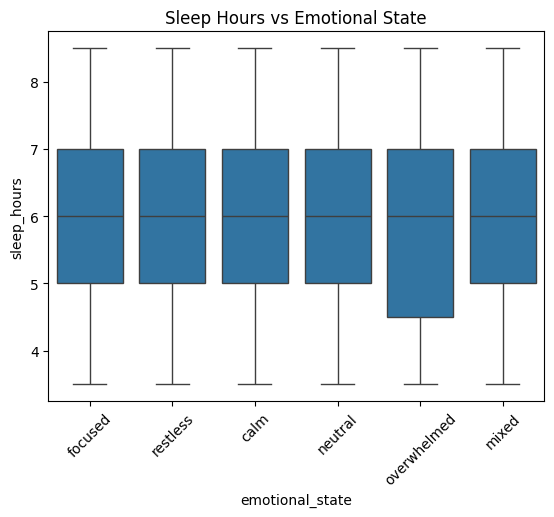

In [81]:
sns.boxplot(x='emotional_state', y='sleep_hours', data=df)
plt.xticks(rotation=45)
plt.title("Sleep Hours vs Emotional State")
plt.show()


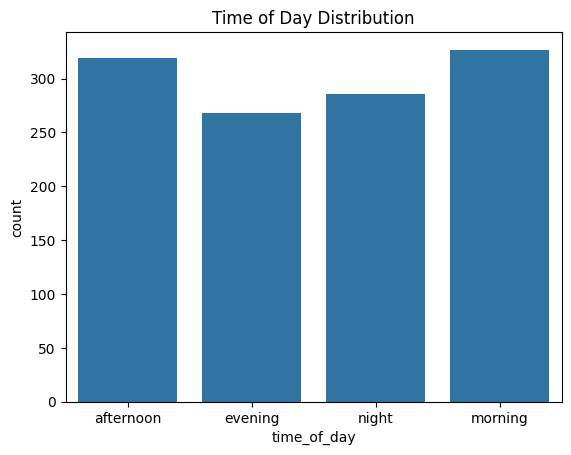

In [82]:
sns.countplot(x='time_of_day', data=df)
plt.title("Time of Day Distribution")
plt.show()


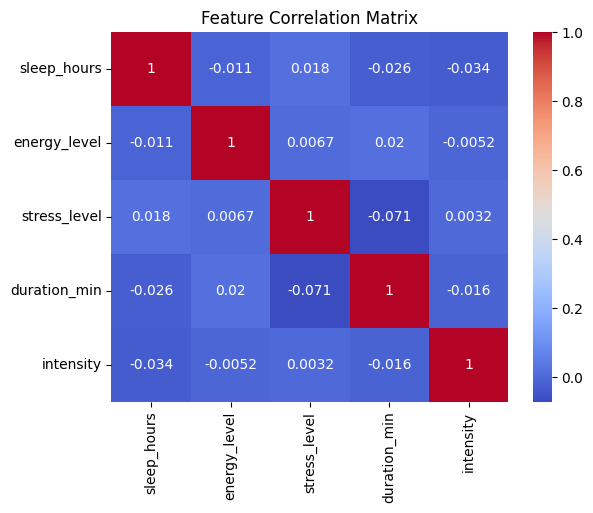

In [83]:
numeric_cols = ['sleep_hours','energy_level','stress_level','duration_min','intensity']

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

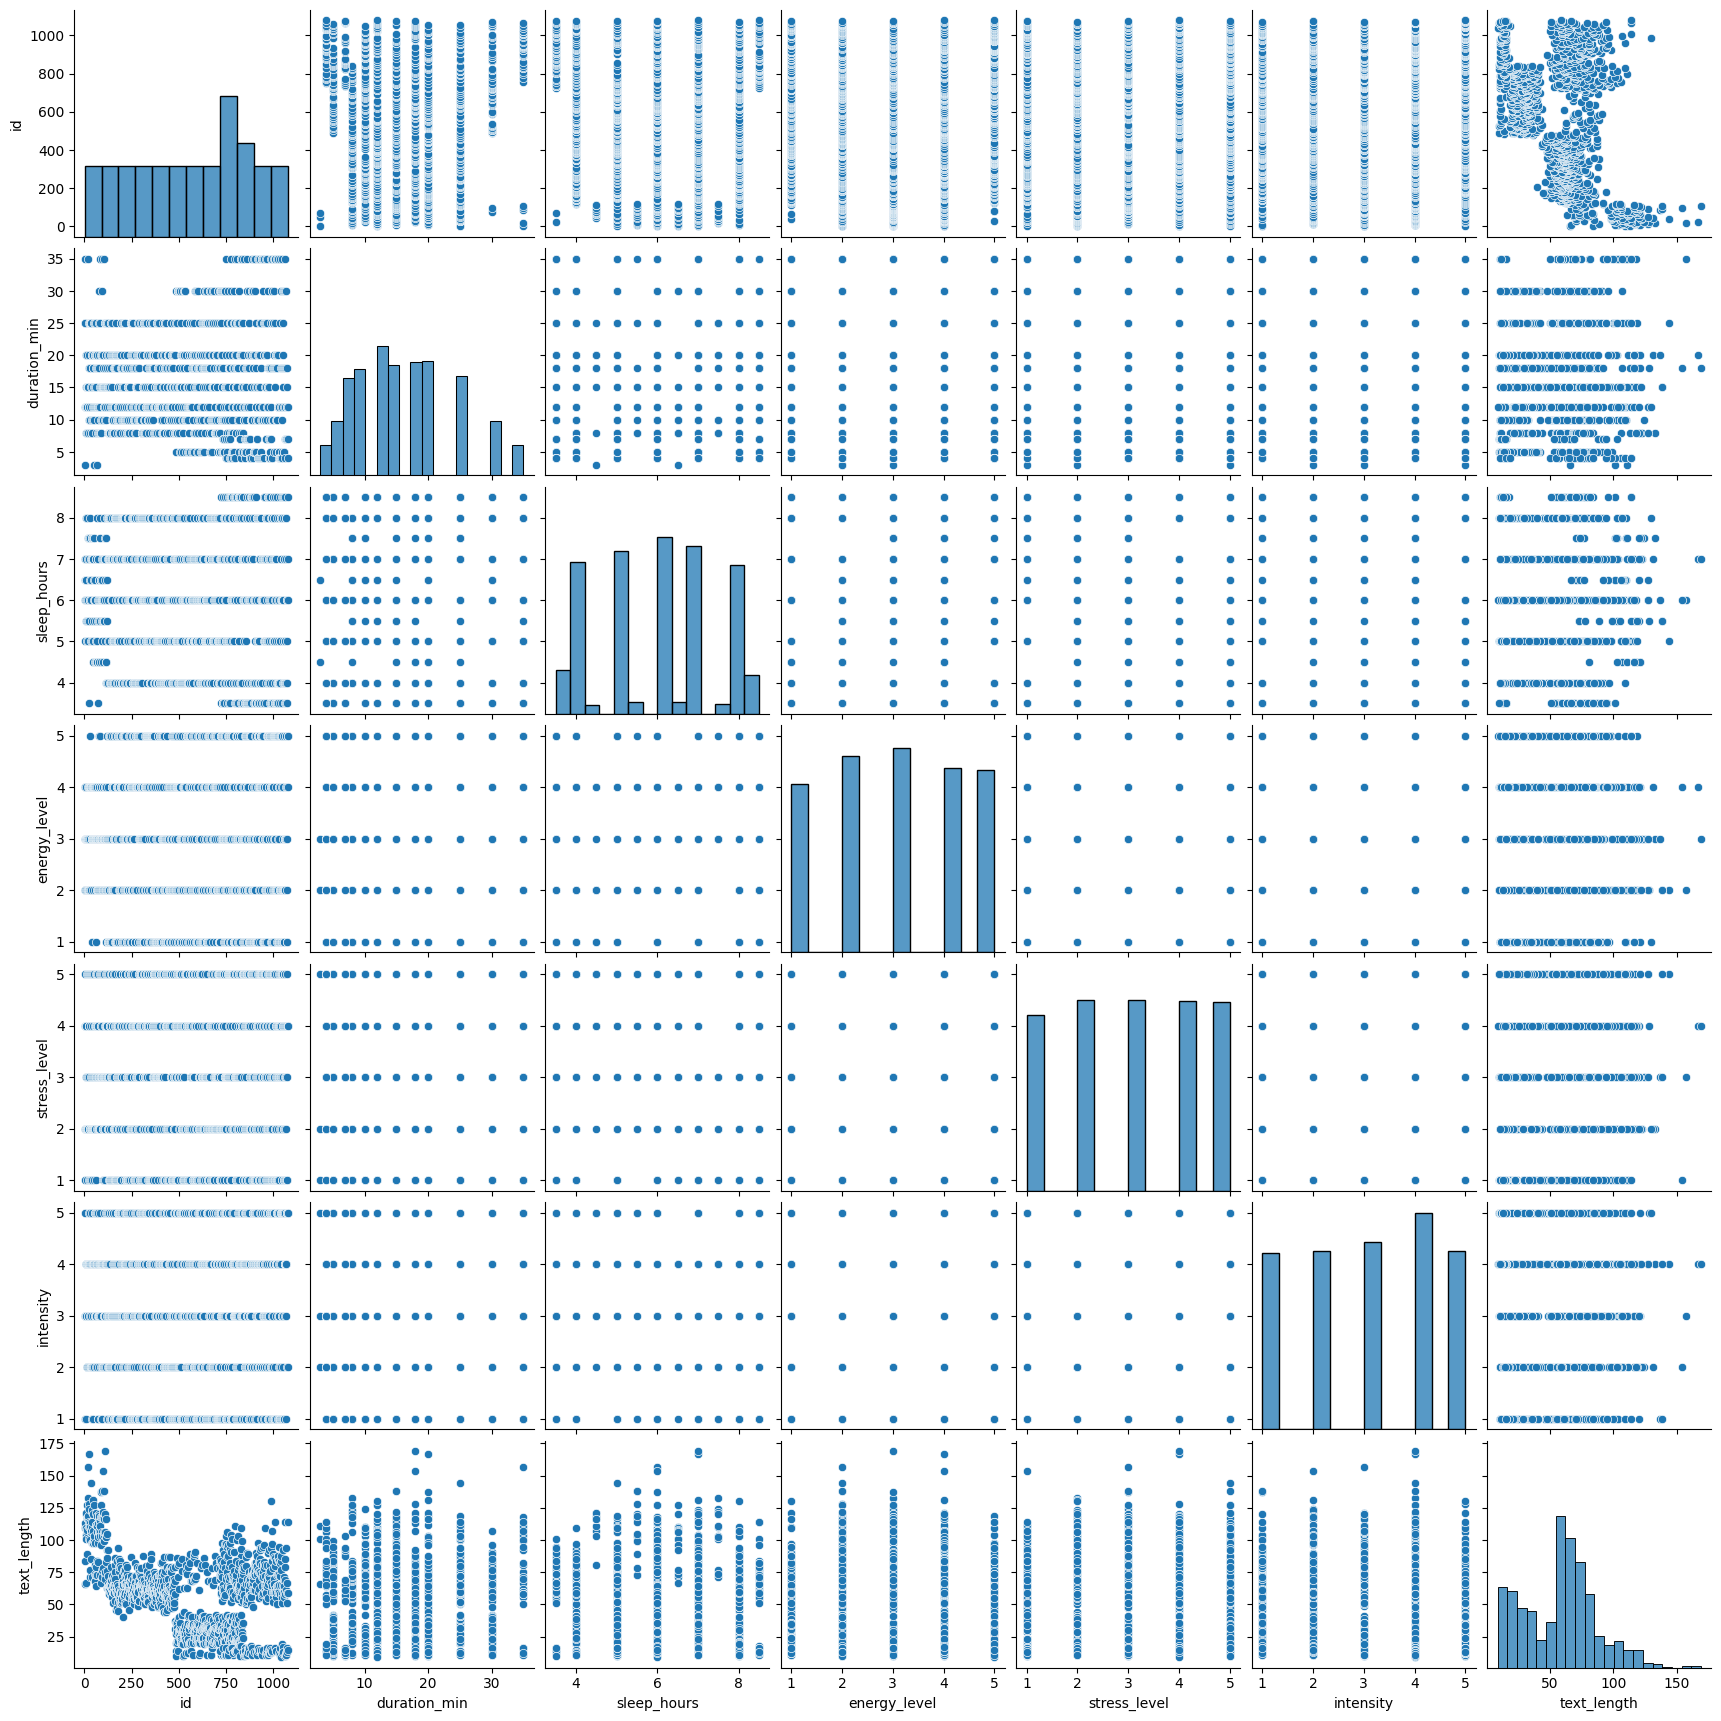

In [84]:
sns.pairplot(df)

In [85]:
df.isnull().sum()

id                      0
journal_text            0
ambience_type           0
duration_min            0
sleep_hours             7
energy_level            0
stress_level            0
time_of_day             0
previous_day_mood      15
face_emotion_hint     123
reflection_quality      0
emotional_state         0
intensity               0
text_length             0
dtype: int64

In [86]:
df['sleep_hours'] = df['sleep_hours'].fillna(df['sleep_hours'].median())
test_data['sleep_hours'] = test_data['sleep_hours'].fillna(test_data['sleep_hours'].median())

In [87]:
df['previous_day_mood'] = df['previous_day_mood'].fillna("unknown")
test_data['previous_day_mood'] = test_data['previous_day_mood'].fillna("unknown")
df['face_emotion_hint'] = df['face_emotion_hint'].fillna('none')
test_data['face_emotion_hint'] = test_data['face_emotion_hint'].fillna('none')

In [88]:
df['face_emotion_hint'].value_counts().sum()

1200

In [89]:
test_data.columns

Index(['id', 'journal_text', 'ambience_type', 'duration_min', 'sleep_hours',
       'energy_level', 'stress_level', 'time_of_day', 'previous_day_mood',
       'face_emotion_hint', 'reflection_quality', 'text_length'],
      dtype='object')

In [90]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /Users/nitin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [91]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

In [92]:
def clean_text(text):
    
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    text = " ".join(words)

    return text

In [93]:
df['clean_text'] = df['journal_text'].apply(clean_text)
test_data['clean_text'] = test_data['journal_text'].apply(clean_text)

In [94]:
df['word_count'] = df['journal_text'].apply(lambda x: len(str(x).split()))
test_data['word_count'] = test_data['journal_text'].apply(lambda x: len(str(x).split()))

In [95]:
df['word_count']

0       19
1       22
2       12
3       15
4       23
        ..
1195    12
1196    11
1197     3
1198    11
1199    22
Name: word_count, Length: 1200, dtype: int64

In [96]:
categorical_cols = [
    'ambience_type',
    'time_of_day',
    'previous_day_mood',
    'face_emotion_hint',
    'reflection_quality'
]
df = pd.get_dummies(df, columns=categorical_cols)
test_data = pd.get_dummies(test_data, columns=categorical_cols)

In [97]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [98]:
numeric_cols = [
    'sleep_hours',
    'energy_level',
    'stress_level',
    'duration_min',
    'text_length',
    'word_count'
]
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
test_data[numeric_cols] = scaler.fit_transform(test_data[numeric_cols])

In [2287]:
df.head(5)

,id,journal_text,duration_min,sleep_hours,energy_level,stress_level,emotional_state,intensity,text_length,clean_text,...,previous_day_mood_unknown,face_emotion_hint_calm_face,face_emotion_hint_happy_face,face_emotion_hint_neutral_face,face_emotion_hint_none,face_emotion_hint_tense_face,face_emotion_hint_tired_face,reflection_quality_clear,reflection_quality_conflicted,reflection_quality_vague
0,1,The ocean ambience helped me stop drifting and...,-0.503597,0.341251,0.712189,-0.732843,focused,3,1.823606,ocean ambience helped stop drifting concentrat...,...,False,True,False,False,False,False,False,True,False,False
1,2,"I tried to relax during the forest ambience, y...",2.495814,0.006964,-0.736331,0.694773,restless,3,1.788316,tried relax forest ambience yet thoughts kept ...,...,False,False,False,False,False,False,True,False,False,True
2,3,The forest session slowed my thoughts and I fe...,-1.677279,0.006964,-0.736331,-1.446652,calm,3,0.270850,forest session slowed thoughts feel settled,...,False,False,True,False,False,False,False,True,False,False
3,4,"the mountain ambience was pleasant, though i c...",1.191723,0.675538,0.712189,0.694773,neutral,1,0.906068,mountain ambience pleasant though cant say shi...,...,False,True,False,False,False,False,False,False,False,True
4,5,"The rain session gave me a pause, but the pres...",1.191723,-0.661609,-0.012071,1.408582,overwhelmed,5,1.929476,rain session gave pause pressure still sitting...,...,True,False,False,False,False,True,False,True,False,False


In [2288]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

In [2289]:
X_text = tfidf.fit_transform(df['clean_text'])
X_meta = df.drop(columns=['clean_text', 'emotional_state', 'intensity', 'id', 'journal_text'])
y = df[['emotional_state', 'intensity']]

X_train_text, X_test_error_text, X_train_meta, X_test_error_meta, y_train, y_test = train_test_split(
    X_text,
    X_meta,
    y,
    test_size=0.2,
    random_state=42
)


In [2290]:
y_state = y_train['emotional_state']
y_intensity = y_train['intensity']

In [2291]:
df, test_data = df.align(test_data, join='left', axis=1, fill_value=0)

In [2292]:
X_test = test_data.drop(['id','journal_text'], axis=1)

In [2293]:
X_train.head()

,duration_min,sleep_hours,energy_level,stress_level,text_length,clean_text,word_count,ambience_type_cafe,ambience_type_forest,ambience_type_mountain,...,face_emotion_hint_calm_face,face_emotion_hint_happy_face,face_emotion_hint_neutral_face,face_emotion_hint_none,face_emotion_hint_tense_face,face_emotion_hint_tired_face,face_emotion_hint_unknown,reflection_quality_clear,reflection_quality_conflicted,reflection_quality_vague
331,0.539677,1.344112,1.436448,1.408582,0.482589,one point session passed quietly wasnt expecting,0.397212,False,False,True,...,False,False,True,False,False,False,False,False,True,False
409,0.539677,1.344112,1.436448,-0.019035,0.870778,honestly part relaxed anotehr part stayed busy...,0.776261,False,False,False,...,False,True,False,False,False,False,False,True,False,False
76,0.278858,-0.995896,-0.736331,-0.732843,2.035345,forest sounds feel better completely okay cant...,2.102933,False,True,False,...,True,False,False,False,False,False,False,True,False,False
868,-0.112369,-0.661609,-1.460590,1.408582,1.364837,end somewhat settled still uneasy mountain vis...,1.344835,False,True,False,...,True,False,False,False,False,False,False,False,False,True
138,1.191723,1.344112,-1.460590,1.408582,0.270850,reason things felt peaceful didnt last long,0.207687,False,False,False,...,False,False,True,False,False,False,False,False,False,True


In [2294]:
X_test.head(5)

,duration_min,sleep_hours,energy_level,stress_level,emotional_state,intensity,text_length,clean_text,word_count,ambience_type_cafe,...,previous_day_mood_unknown,face_emotion_hint_calm_face,face_emotion_hint_happy_face,face_emotion_hint_neutral_face,face_emotion_hint_none,face_emotion_hint_tense_face,face_emotion_hint_tired_face,reflection_quality_clear,reflection_quality_conflicted,reflection_quality_vague
0,-1.148781,1.277022,0.105557,-1.301648,0,0,0.296796,woke feeling organized mentally tired thought,0.149188,True,...,False,False,True,False,False,False,False,False,False,True
1,-1.148781,1.277022,-1.227797,-0.601209,0,0,0.258705,started distracted time better yesterday,-0.054250,False,...,False,False,True,False,False,False,False,True,False,False
2,0.012315,1.277022,-0.561120,1.500105,0,0,-1.950601,kinda calm,-1.885190,True,...,False,False,True,False,False,False,False,False,False,True
3,-0.832119,0.459001,-0.561120,0.099229,0,0,0.639620,session felt able think straight breathing slo...,0.556063,False,...,False,False,False,False,True,False,False,True,False,False
4,0.540085,1.277022,-1.227797,1.500105,0,0,-0.388851,lowkey felt pretty grounded restart,-0.461126,False,...,False,False,False,False,False,False,True,False,False,True


In [2295]:
X_test_meta = X_test.drop(columns=['clean_text']) 
X_test_text = tfidf.transform(test_data['clean_text'])


In [2296]:
X_test_meta = X_test_meta[X_train_meta.columns]

In [2297]:
X_test_error_meta = X_test_error_meta[X_train_meta.columns]

In [2298]:
X_train_meta.head()

,duration_min,sleep_hours,energy_level,stress_level,text_length,word_count,ambience_type_cafe,ambience_type_forest,ambience_type_mountain,ambience_type_ocean,...,previous_day_mood_unknown,face_emotion_hint_calm_face,face_emotion_hint_happy_face,face_emotion_hint_neutral_face,face_emotion_hint_none,face_emotion_hint_tense_face,face_emotion_hint_tired_face,reflection_quality_clear,reflection_quality_conflicted,reflection_quality_vague
331,0.539677,1.344112,1.436448,1.408582,0.482589,0.397212,False,False,True,False,...,False,False,False,True,False,False,False,False,True,False
409,0.539677,1.344112,1.436448,-0.019035,0.870778,0.776261,False,False,False,True,...,False,False,True,False,False,False,False,True,False,False
76,0.278858,-0.995896,-0.736331,-0.732843,2.035345,2.102933,False,True,False,False,...,False,True,False,False,False,False,False,True,False,False
868,-0.112369,-0.661609,-1.460590,1.408582,1.364837,1.344835,False,True,False,False,...,True,True,False,False,False,False,False,False,False,True
138,1.191723,1.344112,-1.460590,1.408582,0.270850,0.207687,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True


In [2299]:
X_test_meta.head()

,duration_min,sleep_hours,energy_level,stress_level,text_length,word_count,ambience_type_cafe,ambience_type_forest,ambience_type_mountain,ambience_type_ocean,...,previous_day_mood_unknown,face_emotion_hint_calm_face,face_emotion_hint_happy_face,face_emotion_hint_neutral_face,face_emotion_hint_none,face_emotion_hint_tense_face,face_emotion_hint_tired_face,reflection_quality_clear,reflection_quality_conflicted,reflection_quality_vague
0,-1.148781,1.277022,0.105557,-1.301648,0.296796,0.149188,True,False,False,False,...,False,False,True,False,False,False,False,False,False,True
1,-1.148781,1.277022,-1.227797,-0.601209,0.258705,-0.054250,False,False,True,False,...,False,False,True,False,False,False,False,True,False,False
2,0.012315,1.277022,-0.561120,1.500105,-1.950601,-1.885190,True,False,False,False,...,False,False,True,False,False,False,False,False,False,True
3,-0.832119,0.459001,-0.561120,0.099229,0.639620,0.556063,False,False,False,True,...,False,False,False,False,True,False,False,True,False,False
4,0.540085,1.277022,-1.227797,1.500105,-0.388851,-0.461126,False,False,False,True,...,False,False,False,False,False,False,True,False,False,True


In [2300]:
X_test_error_meta.head()

,duration_min,sleep_hours,energy_level,stress_level,text_length,word_count,ambience_type_cafe,ambience_type_forest,ambience_type_mountain,ambience_type_ocean,...,previous_day_mood_unknown,face_emotion_hint_calm_face,face_emotion_hint_happy_face,face_emotion_hint_neutral_face,face_emotion_hint_none,face_emotion_hint_tense_face,face_emotion_hint_tired_face,reflection_quality_clear,reflection_quality_conflicted,reflection_quality_vague
1178,-0.503597,0.675538,1.436448,-1.446652,0.200270,0.018163,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
865,-0.112369,1.344112,1.436448,-0.019035,0.694329,0.965786,False,False,False,True,...,False,True,False,False,False,False,False,False,True,False
101,-0.503597,0.675538,-0.012071,-1.446652,1.611866,1.344835,False,True,False,False,...,False,False,False,False,True,False,False,True,False,False
439,-0.112369,-0.661609,-0.736331,0.694773,-0.434948,-0.739936,False,True,False,False,...,False,False,True,False,False,False,False,True,False,False
58,-1.025233,0.675538,-0.012071,-0.019035,0.729619,0.397212,False,False,True,False,...,False,True,False,False,False,False,False,True,False,False


In [2301]:
X_train_meta.dtypes

duration_min                      float64
sleep_hours                       float64
energy_level                      float64
stress_level                      float64
text_length                       float64
word_count                        float64
ambience_type_cafe                   bool
ambience_type_forest                 bool
ambience_type_mountain               bool
ambience_type_ocean                  bool
ambience_type_rain                   bool
time_of_day_afternoon                bool
time_of_day_evening                  bool
time_of_day_morning                  bool
time_of_day_night                    bool
previous_day_mood_calm               bool
previous_day_mood_focused            bool
previous_day_mood_mixed              bool
previous_day_mood_neutral            bool
previous_day_mood_overwhelmed        bool
previous_day_mood_restless           bool
previous_day_mood_unknown            bool
face_emotion_hint_calm_face          bool
face_emotion_hint_happy_face      

In [2302]:
X_train_meta = X_train_meta.astype(float)
X_test_meta = X_test_meta.astype(float)
X_test_error_meta = X_test_error_meta.astype(float)

In [2303]:
from scipy.sparse import csr_matrix

X_train_meta = csr_matrix(X_train_meta.values)
X_test_meta = csr_matrix(X_test_meta.values)
X_test_error_meta = csr_matrix(X_test_error_meta.values)

In [2304]:
X_train_final = hstack([X_train_text, X_train_meta])
X_test_final  = hstack([X_test_text, X_test_meta])
X_test_error_final  = hstack([X_test_error_text, X_test_error_meta])

In [2305]:
X_train_final.shape

(960, 1623)

In [2306]:
X_test_final.shape

(120, 1623)

In [2307]:
le = LabelEncoder()

y_state_encoded = le.fit_transform(y_state)

In [2308]:
state_model = LogisticRegression(max_iter=1000, C=10, solver='liblinear')

state_model.fit(X_train_final, y_state_encoded)

LogisticRegression(C=10, max_iter=1000, solver='liblinear')

In [2309]:
state_predictions = state_model.predict(X_test_final)
state_predictions_error = state_model.predict(X_test_error_final)

In [2310]:
state_predictions


array([1, 5, 1, 1, 0, 2, 5, 4, 5, 4, 4, 0, 2, 1, 0, 5, 2, 2, 1, 0, 4, 0,
       4, 3, 0, 4, 3, 0, 4, 0, 1, 2, 4, 3, 1, 5, 1, 1, 2, 2, 4, 0, 0, 0,
       5, 1, 1, 0, 5, 5, 0, 5, 0, 4, 2, 1, 4, 4, 2, 3, 3, 5, 5, 0, 3, 5,
       5, 4, 3, 3, 2, 3, 5, 2, 5, 2, 3, 5, 5, 1, 5, 1, 3, 4, 0, 5, 2, 3,
       3, 2, 3, 4, 2, 1, 4, 0, 0, 4, 2, 2, 2, 4, 2, 2, 0, 3, 5, 3, 0, 0,
       2, 2, 0, 0, 0, 4, 3, 1, 2, 5])

In [2311]:
predicted_states = le.inverse_transform(state_predictions)
predicted_states_error = le.inverse_transform(state_predictions_error)


In [2312]:
state_probs = state_model.predict_proba(X_test_final)

confidence_scores = state_probs.max(axis=1)

In [2313]:
uncertain_flag = (confidence_scores < 0.55).astype(int)

In [2314]:
uncertain_flag

array([0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0])

In [2315]:
intensity_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=6
)

intensity_model.fit(X_train_final,y_intensity)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.5, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [2316]:
predicted_intensity = intensity_model.predict(X_test_final)
predicted_intensity_error = intensity_model.predict(X_test_error_final)

In [2317]:
predicted_intensity = np.clip(np.round(predicted_intensity),1,5)
predicted_intensity_error = np.clip(np.round(predicted_intensity_error),1,5)

In [2318]:
predicted_intensity

array([3., 5., 3., 4., 3., 4., 5., 3., 5., 3., 3., 4., 4., 2., 4., 5., 4.,
       1., 4., 4., 3., 1., 3., 1., 5., 3., 3., 2., 2., 2., 4., 3., 2., 3.,
       5., 2., 4., 4., 2., 3., 3., 4., 4., 2., 4., 3., 4., 4., 3., 2., 2.,
       2., 4., 4., 2., 2., 3., 4., 4., 2., 2., 3., 4., 3., 4., 1., 2., 4.,
       3., 3., 3., 1., 2., 2., 3., 2., 4., 4., 3., 4., 2., 3., 5., 1., 2.,
       3., 3., 5., 3., 3., 4., 2., 5., 4., 2., 3., 2., 3., 3., 4., 2., 3.,
       4., 1., 3., 3., 5., 3., 3., 3., 4., 3., 4., 3., 3., 3., 5., 4., 4.,
       4.], dtype=float32)

In [2319]:
predicted_intensity_error

array([2., 3., 3., 2., 3., 4., 5., 4., 2., 2., 2., 3., 4., 2., 3., 4., 2.,
       2., 5., 2., 3., 4., 2., 3., 3., 3., 3., 4., 5., 4., 3., 4., 3., 3.,
       3., 4., 4., 4., 4., 3., 3., 3., 3., 4., 4., 2., 2., 4., 3., 2., 4.,
       3., 3., 3., 4., 2., 3., 3., 3., 2., 4., 2., 3., 3., 3., 2., 3., 3.,
       3., 4., 1., 2., 4., 3., 3., 1., 3., 3., 4., 4., 3., 1., 5., 2., 2.,
       2., 2., 4., 4., 3., 5., 2., 5., 3., 4., 5., 2., 5., 3., 5., 4., 3.,
       3., 2., 4., 3., 4., 5., 3., 3., 4., 3., 3., 1., 2., 3., 2., 2., 2.,
       3., 3., 4., 5., 3., 2., 1., 4., 3., 1., 3., 4., 2., 3., 4., 5., 3.,
       3., 2., 1., 3., 3., 2., 4., 5., 4., 3., 4., 1., 3., 3., 2., 3., 3.,
       2., 4., 2., 3., 4., 3., 1., 2., 2., 5., 3., 3., 2., 4., 3., 2., 3.,
       4., 3., 3., 3., 2., 2., 4., 3., 4., 1., 3., 2., 3., 3., 3., 3., 3.,
       3., 2., 4., 2., 1., 3., 3., 3., 3., 2., 4., 4., 2., 4., 2., 3., 4.,
       3., 3., 4., 4., 4., 4., 1., 2., 4., 4., 2., 3., 5., 3., 2., 2., 3.,
       3., 4., 5., 2., 2.

In [2320]:
predictions = pd.DataFrame()

predictions['id'] = test_data['id']
predictions['predicted_state'] = predicted_states
predictions['predicted_intensity'] = predicted_intensity
predictions['confidence'] = confidence_scores
predictions['uncertain_flag'] = uncertain_flag

In [2321]:
predictions.describe()

,id,predicted_intensity,confidence,uncertain_flag
count,120.000000,120.000000,120.000000,120.000000
mean,10060.500000,3.150000,0.615996,0.366667
std,34.785054,1.042379,0.185034,0.483915
min,10001.000000,1.000000,0.217669,0.000000
25%,10030.750000,2.000000,0.481574,0.000000
50%,10060.500000,3.000000,0.635171,0.000000
75%,10090.250000,4.000000,0.781234,1.000000
max,10120.000000,5.000000,0.895159,1.000000


In [2322]:
predictions['stress_level'] = test_data_raw['stress_level']
predictions['energy_level'] = test_data_raw['energy_level']
predictions['time_of_day'] = test_data_raw['time_of_day']

In [2323]:
def decision_engine(row):
    
    stress = row['stress_level']
    energy = row['energy_level']
    intensity = row['predicted_intensity']
    confidence = row['confidence']
    state = row['predicted_state']
    time = row['time_of_day']
    
    what_to_do = "pause"
    when_to_do = "within_15_min"
    
    # UNCERTAINTY
    if confidence < 0.4:
        return pd.Series(["pause", "within_15_min"])
    
    # HIGH STRESS + HIGH INTENSITY
    if (stress >= 4 or intensity >= 4) and state!='restless':
        return pd.Series(["box_breathing", "now"])
    
    # LOW ENERGY
    if energy <= 2:
        if time in ["night", "evening"]:
            return pd.Series(["rest", "tonight"])
        else:
            return pd.Series(["movement", "within_15_min"])
    
    # HIGH ENERGY + FOCUSED
    if energy >= 4 and state == "focused":
        return pd.Series(["deep_work", "now"])
    
    # ANXIOUS / RESTLESS
    if state in ["anxious", "restless"]:
        return pd.Series(["grounding", "within_15_min"])
    
    # SAD / OVERWHELMED
    if state in ["sad", "overwhelmed"]:
        return pd.Series(["journaling", "tonight"])
    
    # CALM STATE
    if state in ["calm", "content"]:
        return pd.Series(["light_planning", "later_today"])
    
    return pd.Series([what_to_do, when_to_do])



In [2324]:
predictions[['what_to_do','when_to_do']] = predictions.apply(decision_engine, axis=1)

In [2325]:
predictions.sample(20)

,id,predicted_state,predicted_intensity,confidence,uncertain_flag,stress_level,energy_level,time_of_day,what_to_do,when_to_do
36,10037,focused,4.0,0.342309,1,5,3,morning,pause,within_15_min
4,10005,calm,3.0,0.487972,1,5,1,afternoon,box_breathing,now
19,10020,calm,4.0,0.415254,1,2,1,evening,box_breathing,now
105,10106,neutral,3.0,0.781136,0,3,5,afternoon,pause,within_15_min
20,10021,overwhelmed,3.0,0.787819,0,5,1,evening,box_breathing,now
74,10075,restless,3.0,0.466821,1,4,3,morning,grounding,within_15_min
33,10034,neutral,3.0,0.769070,0,4,1,night,box_breathing,now
67,10068,overwhelmed,4.0,0.839168,0,5,5,morning,box_breathing,now
113,10114,calm,3.0,0.357838,1,4,3,afternoon,pause,within_15_min
82,10083,neutral,5.0,0.739425,0,3,4,afternoon,box_breathing,now


In [2326]:
predictions = predictions.drop(columns=['stress_level','energy_level','time_of_day'])

In [2327]:
predictions

,id,predicted_state,predicted_intensity,confidence,uncertain_flag,what_to_do,when_to_do
0,10001,focused,3.0,0.653596,0,pause,within_15_min
1,10002,restless,5.0,0.372052,1,pause,within_15_min
2,10003,focused,3.0,0.419092,1,box_breathing,now
3,10004,focused,4.0,0.810084,0,box_breathing,now
4,10005,calm,3.0,0.487972,1,box_breathing,now
...,...,...,...,...,...,...,...
115,10116,overwhelmed,3.0,0.878286,0,journaling,tonight
116,10117,neutral,5.0,0.337232,1,pause,within_15_min
117,10118,focused,4.0,0.777299,0,box_breathing,now
118,10119,mixed,4.0,0.822508,0,box_breathing,now


In [2328]:
predictions['confidence'] = predictions['confidence'].round(2)

In [2329]:
predictions.to_csv('predictions.csv',index=False)

In [2330]:
y_test_state = predictions['predicted_state']

In [2331]:
y_test_state

0          focused
1         restless
2          focused
3          focused
4             calm
          ...     
115    overwhelmed
116        neutral
117        focused
118          mixed
119       restless
Name: predicted_state, Length: 120, dtype: object

In [2332]:
y_test_error_state = y_test['emotional_state']
y_test_error_intensity = y_test['intensity']

In [2333]:
text_model = LogisticRegression(max_iter=1000)
text_model.fit(X_train_text, y_state)

y_pred_text = text_model.predict(X_test_error_text)
acc_text = accuracy_score(y_test_error_state, y_pred_text)

print("Text-only Accuracy:", acc_text)

Text-only Accuracy: 0.6333333333333333


In [2334]:
meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(X_train_meta, y_state)

y_pred_meta = meta_model.predict(X_test_error_meta)
acc_meta = accuracy_score(y_test_error_state, y_pred_meta)

print("Metadata-only Accuracy:", acc_meta)

Metadata-only Accuracy: 0.1875


In [2335]:
combined_model = LogisticRegression(max_iter=1000)
combined_model.fit(X_train_final, y_state)

y_pred_combined = combined_model.predict(X_test_error_final)
acc_combined = accuracy_score(y_test_error_state, y_pred_combined)

print("Text + Metadata Accuracy:", acc_combined)

Text + Metadata Accuracy: 0.5625


In [2336]:
meta_reg = RandomForestRegressor()
meta_reg.fit(X_train_meta, y_intensity)
y_pred_meta_int = meta_reg.predict(X_test_error_meta)
mse_meta = mean_squared_error(y_test_error_intensity, y_pred_meta_int)

print("Metadata-only MSE:", mse_meta)


Metadata-only MSE: 2.08034375


In [ ]:
X_train

,duration_min,sleep_hours,energy_level,stress_level,text_length,clean_text,word_count,ambience_type_cafe,ambience_type_forest,ambience_type_mountain,...,face_emotion_hint_calm_face,face_emotion_hint_happy_face,face_emotion_hint_neutral_face,face_emotion_hint_none,face_emotion_hint_tense_face,face_emotion_hint_tired_face,face_emotion_hint_unknown,reflection_quality_clear,reflection_quality_conflicted,reflection_quality_vague
331,0.539677,1.344112,1.436448,1.408582,0.482589,one point session passed quietly wasnt expecting,0.397212,False,False,True,...,False,False,True,False,False,False,False,False,True,False
409,0.539677,1.344112,1.436448,-0.019035,0.870778,honestly part relaxed anotehr part stayed busy...,0.776261,False,False,False,...,False,True,False,False,False,False,False,True,False,False
76,0.278858,-0.995896,-0.736331,-0.732843,2.035345,forest sounds feel better completely okay cant...,2.102933,False,True,False,...,True,False,False,False,False,False,False,True,False,False
868,-0.112369,-0.661609,-1.460590,1.408582,1.364837,end somewhat settled still uneasy mountain vis...,1.344835,False,True,False,...,True,False,False,False,False,False,False,False,False,True
138,1.191723,1.344112,-1.460590,1.408582,0.270850,reason things felt peaceful didnt last long,0.207687,False,False,False,...,False,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044,2.495814,-1.330183,-0.012071,-0.732843,0.588459,gonna lie felt unable stay one thought ocean a...,0.776261,False,False,True,...,False,False,True,False,False,False,False,True,False,False
1095,-0.112369,1.344112,1.436448,1.408582,-1.670095,felt better,-1.687558,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1130,2.495814,-1.330183,1.436448,-0.732843,0.129690,mostly sleep probably affected,0.207687,False,False,False,...,False,False,False,False,True,False,False,False,False,True
860,1.843768,-0.661609,1.436448,-1.446652,1.082518,started bad clear either couldnt tell helping ...,1.344835,False,False,False,...,True,False,False,False,False,False,False,True,False,False


In [2338]:
error_analysis = pd.DataFrame()

error_analysis['state'] = y_test_error_state
error_analysis['intensity'] = y_test_error_intensity
error_analysis['predicted_state'] = predicted_states_error
error_analysis['predicted_intensity'] = predicted_intensity_error

In [2339]:
error_analysis['predicted_intensity'] = error_analysis['predicted_intensity'].astype(int)

In [2340]:
error_analysis = error_analysis.reset_index()

In [2341]:
error_analysis = error_analysis.rename(columns={'index': 'id'})

In [2356]:
error_column = error_analysis[
    (error_analysis['state'] != error_analysis['predicted_state']) &
    (error_analysis['intensity'] != error_analysis['predicted_intensity'])
]

In [2344]:
error_analysis[error_analysis['state']==error_analysis['predicted_state']]

,id,state,intensity,predicted_state,predicted_intensity
0,1178,neutral,5,neutral,2
1,865,overwhelmed,2,overwhelmed,3
2,101,calm,2,calm,3
3,439,restless,5,restless,2
4,58,focused,3,focused,3
...,...,...,...,...,...
228,231,overwhelmed,2,overwhelmed,3
230,333,neutral,1,neutral,3
231,129,restless,4,restless,4
232,1011,overwhelmed,4,overwhelmed,1


In [2367]:
error_analysis[error_analysis['intensity']==error_analysis['predicted_intensity']]

,id,state,intensity,predicted_state,predicted_intensity
4,58,focused,3,focused,3
10,820,calm,2,restless,2
12,49,restless,4,restless,4
14,240,neutral,3,neutral,3
21,609,focused,4,mixed,4
24,109,focused,3,focused,3
27,570,mixed,4,restless,4
32,692,neutral,3,overwhelmed,3
46,354,overwhelmed,2,overwhelmed,2
47,23,mixed,4,mixed,4


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), params, cv=5)
grid.fit(X_train_final, y_state_encoded)

print(grid.best_params_)

{'C': 10, 'solver': 'liblinear'}


In [2365]:
params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=1
)

grid.fit(X_train_final, y_intensity)

print(grid.best_params_)

{'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}


In [2345]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=6
)

model.fit(X_train_final,y_intensity)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.5, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [2346]:
x = model.predict(X_test_error_final)
x = np.clip(np.round(x),1,5)

In [2347]:
x.shape

(240,)

In [2348]:
X_test_error_final.shape

(240, 1623)

In [2364]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=6,   
    cv=3,
    n_jobs=1,
    verbose=2
)

random_search.fit(X_train_final, y_train['intensity'])

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, n_estimators=200, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, n_estimators=200, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, n_estimators=200, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=6, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=6, n_estimators=200, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=6, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=6, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=6, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsa

RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=...
                                          max_delta_step=None, max_depth=6,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=100,
                                          n_jobs=None, num_parallel_tree=None,
                                          random_state=None, ...),
                   n_iter=6, n_jobs=1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.05, 0.1],
                                        'max_depth': [6, 8],
                                        'n_estimators': [100, 200],
                                        'subsample': [0.8, 1.0]},
                   verbose=2)

In [2350]:
print("Best parameters:", random_search.best_params_)
print("Best CV score (R²):", random_search.best_score_)

Best parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV score (R²): -0.05466141509798975


In [2351]:
x1 = model.predict(X_test_error_final)
x1 = np.clip(np.round(x1),1,5)

In [2357]:
error_id = error_column['id'].values 

In [2358]:
error_id

array([ 855,  523,  765,  676,  677,  598,  893,  727,  596,  652,  950,
        737, 1135, 1115,  988, 1172,  377,  994,  549,  490,  850,  548,
        615,  513,  670,  534,  735,  739, 1166,  621,  158, 1003,  694,
        630,  622,  643,  925, 1097,  636,  767,  532,  666,  597, 1102,
        728,  933,  887,  762,  953,  787,  826, 1039,  834,  830,  693,
        996,  907,  657,  956,  788,  713,  789,  631,  558,  967, 1004,
        984,  519,  770,  620,  644,  973,  867, 1193,  874])

In [2377]:
error_cases = data[data['id'].isin(error_id)]
error_cases.head(10)

,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality,emotional_state,intensity
157,158,By the end my breathing slowed down and I wasn...,cafe,18,4.0,3,5,night,mixed,happy_face,conflicted,calm,3
376,377,At one point my thoughts became clearer for a ...,rain,15,7.0,4,3,morning,overwhelmed,happy_face,clear,focused,5
489,490,By the end got distracted again. ...,cafe,8,7.0,4,4,evening,mixed,NaN,vague,focused,4
512,513,honestly back to normal after.,mountain,15,4.0,3,4,night,focused,tired_face,clear,restless,1
518,519,for some reason okay session.,mountain,20,6.0,2,3,night,overwhelmed,calm_face,conflicted,restless,5
522,523,at first still anxious a bit.,ocean,5,6.0,3,2,night,mixed,neutral_face,conflicted,neutral,3
531,532,honestly not much change,ocean,30,5.0,4,4,morning,restless,none,vague,calm,3
533,534,could focus for a while ...,forest,30,6.0,2,4,afternoon,overwhelmed,tense_face,conflicted,calm,3
547,548,still anxious a bit ...,ocean,15,5.0,2,4,night,restless,none,clear,neutral,1
548,549,During the session helped me plan my day. Late...,cafe,10,4.0,1,1,morning,calm,neutral_face,clear,mixed,5


In [2383]:
error_column.head(10)

,id,state,intensity,predicted_state,predicted_intensity
9,855,calm,4,mixed,2
16,523,calm,5,overwhelmed,2
17,765,mixed,5,focused,2
22,676,neutral,5,mixed,2
26,677,calm,5,overwhelmed,3
29,598,overwhelmed,2,restless,4
31,893,overwhelmed,2,neutral,4
33,727,neutral,2,overwhelmed,3
35,596,mixed,3,focused,4
39,652,neutral,1,overwhelmed,3


In [2382]:
error_cases[error_cases['id'].isin(error_column.head(10)['id'].values)]

,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality,emotional_state,intensity
522,523,at first still anxious a bit.,ocean,5,6.0,3,2,night,mixed,neutral_face,conflicted,neutral,3
595,596,mind was all over the place,ocean,12,6.0,2,2,evening,focused,none,clear,mixed,1
597,598,For some reason still anxious a bit.,ocean,20,8.0,1,1,morning,restless,tense_face,clear,calm,4
651,652,Honestly honestly not much change.,mountain,12,8.0,1,2,morning,overwhelmed,calm_face,vague,restless,2
675,676,i guess back to normal after.,ocean,5,7.0,4,1,morning,overwhelmed,happy_face,clear,mixed,2
676,677,okay session ...,mountain,10,7.0,5,2,evening,restless,none,clear,neutral,5
726,727,could focus for a while,rain,30,4.0,1,3,morning,overwhelmed,calm_face,clear,restless,2
764,765,Honestly helped me plan my day. Later it chang...,mountain,8,6.0,5,1,night,overwhelmed,happy_face,vague,restless,1
846,727,kind of felt mentally flooded. then my mind wa...,ocean,25,3.5,5,5,evening,focused,tense_face,conflicted,overwhelmed,3
884,765,"after the session i felt clearer than earlier,...",forest,20,8.0,3,5,evening,neutral,none,clear,focused,3


In [2]:
import pickle

In [2385]:
with open("models/emotion_model.pkl", "wb") as f:
    pickle.dump(state_model, f)

with open("models/intensity_model.pkl", "wb") as f:
    pickle.dump(intensity_model, f)

In [2386]:
with open("models/tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

In [99]:
with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)